# Medical Insurance Cost Analysis

## Research Question

Before loading the dataset, my question is:

**Do smokers have higher medical insurance charges than non-smokers, and how strong is that difference?**

This question matters because smoking is a major health-related variable, and insurance charges may reflect higher expected medical costs.

In [ ]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the Dataset with Pandas

In [39]:
# Load the insurance dataset
df = pd.read_csv("insurance .csv")

# Print dataset shape
print("Dataset shape:", df.shape)

# Display first few rows
df.head()

Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [36]:
# Check column names, data types, and missing values

print(df.info())
print("\nMissing values per column: ")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing values per column: 
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
# Display summary statistics
print("Dataset info:")
print(df.describe(), "\n")

Dataset info:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010 



The dataset has 1338 rows and 7 columns. Each row represents one individual, and the target variable is `charges`, which represents billed medical insurance costs.

## 2. For Loop with a Running Counter

This loop counts how many numeric columns have an average value greater than 30. This is meaningful because it helps identify numeric variables with larger-scale values.

In [ ]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Running counter
count_above_30 = 0

for col in numeric_cols: # Loop through numeric columns
    mean_value = df[col].mean()
    
    # Counter accumulates columns with mean above 30
    if mean_value > 30:
        count_above_30 += 1
        print(col, "has mean above 30:", mean_value)

print("Number of numeric columns with mean above 30:", count_above_30)

age has mean above 30: 39.20702541106129
bmi has mean above 30: 30.66339686098655
charges has mean above 30: 13270.422265141257
Number of numeric columns with mean above 30: 3


## 3. Conditional Logic

This code uses conditional logic to classify the average medical charge as low, moderate, or high.

In [ ]:
avg_charge = df["charges"].mean() # Calculate average charge

# if branch: average charge is low
if avg_charge < 5000:
    charge_category = "low"

# elif branch: average charge is moderate
elif avg_charge < 15000:
    charge_category = "moderate"

# else branch: average charge is high
else:
    charge_category = "high"

print("Average charge:", avg_charge)
print("Charge category:", charge_category)

Average charge: 13270.422265141257
Charge category: moderate


The average insurance charge falls into the moderate range.

## 4. Write and Call My Own Function

In [ ]:
def compare_group_charges(data, column, group_value): # Function to compare average charges for a specific group
    """
    Returns the average insurance charge for rows where a categorical column
    equals a specific group value.

    Parameters:
    data: pandas DataFrame
    column: categorical column name
    group_value: category to filter by

    Returns:
    Mean insurance charge for that group
    """
    group_data = data[data[column] == group_value] # Filter data for the specified group
    mean_charge = group_data["charges"].mean() # Calculate mean charge for that group
    return mean_charge

In [ ]:
# Call the function twice with different arguments to compare smokers vs non-smokers
smoker_avg = compare_group_charges(df, "smoker", "yes") # Average charge for smokers
nonsmoker_avg = compare_group_charges(df, "smoker", "no") # Average charge for non-smokers

print("Average charge for smokers:", smoker_avg)
print("Average charge for non-smokers:", nonsmoker_avg)
print("Difference:", smoker_avg - nonsmoker_avg)

Average charge for smokers: 32050.23183153284
Average charge for non-smokers: 8434.268297856204
Difference: 23615.963533676637


Smokers have much higher average charges than non-smokers, which directly helps answer the research question.

## 5. Numpy Array Indexing

In [23]:
# Extract charges as a NumPy array
charges_array = df["charges"].to_numpy()

# Vectorized operation: calculate mean
mean_charge = charges_array.mean()

# Boolean masking: find charges greater than the mean
above_average_charges = charges_array[charges_array > mean_charge]

# Index access: retrieve first charge
first_charge = charges_array[0]

print("Mean charge:", mean_charge)
print("Number of people above average charge:", len(above_average_charges))
print("First charge in dataset:", first_charge)

Mean charge: 13270.422265141257
Number of people above average charge: 420
First charge in dataset: 16884.924


Using NumPy shows that the charge column can be analyzed directly as an array. The boolean mask identifies people whose insurance charges are above the dataset average.

## 6. Dictionary Manipulation

This dictionary stores average insurance charges by smoking status.

In [24]:
# Create an empty dictionary
smoker_charge_dict = {}

# Loop through smoker categories and store mean charges
for status in df["smoker"].unique():
    smoker_charge_dict[status] = df[df["smoker"] == status]["charges"].mean()

print(smoker_charge_dict)

# Read values from the dictionary
for status in smoker_charge_dict:
    print(status, "average charge:", smoker_charge_dict[status])

# Identify which group has the highest average charge
highest_group = max(smoker_charge_dict, key=smoker_charge_dict.get)
print("Group with highest average charge:", highest_group)

{'yes': np.float64(32050.23183153284), 'no': np.float64(8434.268297856204)}
yes average charge: 32050.23183153284
no average charge: 8434.268297856204
Group with highest average charge: yes


The dictionary shows that smokers have the highest average insurance charges.

## 7. Two Plots with Matplotlib

### Plot 1: Histogram of Insurance Charges

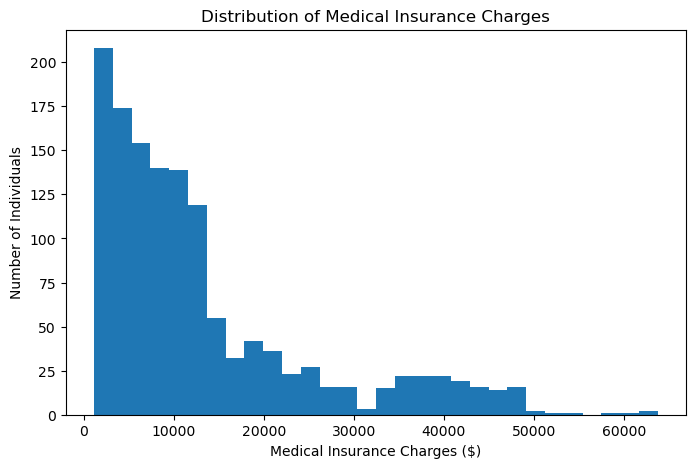

In [ ]:

plt.figure(figsize=(8, 5))
plt.hist(df["charges"], bins=30) # Create histogram of insurance charges
plt.xlabel("Medical Insurance Charges ($)") 
plt.ylabel("Number of Individuals")
plt.title("Distribution of Medical Insurance Charges")
plt.show()

The histogram is right-skewed, not Gaussian. Most people have lower insurance charges, but a smaller number of individuals have very high charges.

### Plot 2: Bar Plot of Average Charges by Smoking Status

I chose this plot because the main research question compares charges between smokers and non-smokers.

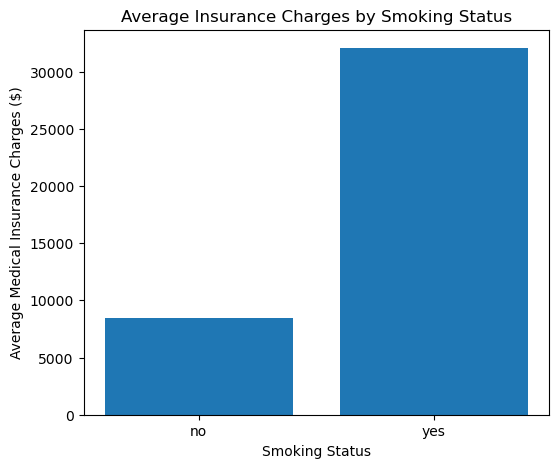

In [ ]:
avg_by_smoker = df.groupby("smoker")["charges"].mean() # Calculate average charges by smoking status

plt.figure(figsize=(6, 5))
plt.bar(avg_by_smoker.index, avg_by_smoker.values) # Create bar chart of average charges by smoking status
plt.xlabel("Smoking Status")
plt.ylabel("Average Medical Insurance Charges ($)")
plt.title("Average Insurance Charges by Smoking Status")
plt.show()

This bar plot shows a clear difference between smokers and non-smokers. Smokers have much higher average charges.

## 8. Advanced Task: Linear Regression

For the advanced task, I will perform a simple linear regression predicting insurance charges from age and BMI.

In [ ]:
# Linear regression to predict charges based on age and bmi
from sklearn.linear_model import LinearRegression # Import LinearRegression from scikit-learn
from sklearn.metrics import r2_score # Import r2_score for evaluating the model

# Select features and target
X = df[["age", "bmi"]]
y = df["charges"]

# Create and fit model
model = LinearRegression()
model.fit(X, y)

# Predict charges
y_pred = model.predict(X)

# Calculate R-squared
r2 = r2_score(y, y_pred)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("R-squared:", r2)

Intercept: -6424.804612240758
Coefficients: [241.9307779  332.96509081]
R-squared: 0.11718338606939949


The R-squared value shows how much of the variation in insurance charges can be explained by age and BMI. Because the value is not very high, age and BMI alone do not fully explain insurance charges, suggesting that other variables such as smoking status are important.

## Conclusion

My original question was whether smokers have higher medical insurance charges than non-smokers. Based on the group averages, dictionary results, and bar plot, smokers clearly have much higher average charges. The linear regression using only age and BMI did not explain charges very strongly, which supports the idea that smoking status is a major factor in insurance cost differences.